# M4 Omnibus Benchmark: Comprehensive Analysis

**Date:** 2026-03-17  
**Data:** `experiments/results/m4/omnibus_benchmark_results.csv`  
**Scope:** 871 runs, 69 named configs (52 unique after deduplication), M4-Yearly (689 runs) and M4-Quarterly (182 runs)

## Key Questions
1. Which architecture wins on M4 across periods?
2. Does the AELG backbone justify its complexity over plain RootBlock?
3. Is `active_g` beneficial or harmful?
4. How do novel wavelet/trend architectures compare to paper baselines?
5. What is the most parameter-efficient competitive configuration?

In [1]:
import pandas as pd
import numpy as np
from scipy import stats as sp_stats
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (14, 6)
matplotlib.rcParams['font.size'] = 11

df = pd.read_csv('../../results/m4/omnibus_benchmark_results.csv')
print(f"Loaded {len(df)} rows, {df['config_name'].nunique()} configs")
print(f"Periods: {sorted(df['period'].unique())}")
print(f"Diverged runs: {df['diverged'].sum()}")

# Identify and remove exact duplicate configs (bd32/64/128 are identical, some naming aliases)
DUPLICATE_CONFIGS = [
    'NBEATS-G-activeG10', 'NBEATS-G-activeG20', 'NBEATS-G-baseline10',
    'NBEATS-I-activeG',  # identical to NBEATS-I-baseline
    'Trend+Coif2WaveletV3-30-activeG_bd64', 'Trend+Coif2WaveletV3-30-activeG_bd128',
    'Trend+Coif2WaveletV3-30_bd64', 'Trend+Coif2WaveletV3-30_bd128',
    'TrendWaveletGeneric-10_bd64', 'TrendWaveletGeneric-10_bd128',
    'TrendWaveletGeneric-10-activeG_bd64', 'TrendWaveletGeneric-10-activeG_bd128',
    'TrendWaveletGeneric-30_bd64', 'TrendWaveletGeneric-30_bd128',
    'TrendAE+Coif2WaveletV3AE-30_bd64', 'TrendAE+Coif2WaveletV3AE-30_bd128',
    'TrendAELG+SynWaveletV3AELG-30-skip',  # identical to DB3 skip variant
]
df_clean = df[~df['config_name'].isin(DUPLICATE_CONFIGS)].copy()
print(f"\nAfter dedup: {len(df_clean)} rows, {df_clean['config_name'].nunique()} configs")

ydf = df_clean[df_clean['period'] == 'Yearly'].copy()
qdf = df_clean[df_clean['period'] == 'Quarterly'].copy()
print(f"Yearly: {len(ydf)} runs, {ydf['config_name'].nunique()} configs")
print(f"Quarterly: {len(qdf)} runs, {qdf['config_name'].nunique()} configs")

Loaded 881 rows, 69 configs
Periods: ['Quarterly', 'Yearly']
Diverged runs: 0

After dedup: 671 rows, 52 configs
Yearly: 520 runs, 52 configs
Quarterly: 151 runs, 16 configs


## 1. Data Quality: The basis_dim Sweep That Wasn't

A significant data quality issue: configs with `_bd32`, `_bd64`, `_bd128` suffixes produce **run-level identical results** to each other. The `forecast_basis_dim` parameter did not take effect -- all three resolve to the same architecture. This affects 6 config groups (18 config names). We keep only the `_bd32` variant from each group and note that the basis_dim sweep needs to be re-run with a corrected implementation.

Similarly, `NBEATS-I-activeG` produces identical results to `NBEATS-I-baseline` (active_g has no effect on Trend/Seasonality blocks), and `NBEATS-G-baseline10/20` are aliases of `NBEATS-G-baseline`.

## 2. M4-Yearly Rankings

The primary benchmark. 52 unique configs, 10 seeds each (one config has 9), all early-stopped, zero divergences.

In [2]:
def compute_stats(data, period):
    sub = data[data['period'] == period]
    stats = sub.groupby('config_name').agg(
        mean_smape=('smape', 'mean'), std_smape=('smape', 'std'),
        mean_mase=('mase', 'mean'), std_mase=('mase', 'std'),
        mean_owa=('owa', 'mean'), std_owa=('owa', 'std'),
        n_runs=('owa', 'count'),
        mean_params=('n_params', 'mean'),
        active_g=('active_g', 'first'),
        arch_family=('arch_family', 'first'),
        backbone=('backbone', 'first'),
        stack_pattern=('stack_pattern', 'first'),
    ).sort_values('mean_owa')
    return stats

y_stats = compute_stats(df_clean, 'Yearly')

# Display top 25
cols = ['mean_smape', 'std_smape', 'mean_mase', 'mean_owa', 'std_owa', 'n_runs', 'arch_family']
display_df = y_stats[cols].head(25).copy()
display_df['params_M'] = y_stats['mean_params'].head(25) / 1e6
display_df = display_df.round({'mean_smape': 3, 'std_smape': 3, 'mean_mase': 4, 'mean_owa': 4, 'std_owa': 4, 'params_M': 2})
print("M4-Yearly: Top 25 by OWA")
print(display_df.to_string())

M4-Yearly: Top 25 by OWA
                                         mean_smape  std_smape  mean_mase  mean_owa  std_owa  n_runs     arch_family  params_M
config_name                                                                                                                   
NBEATS-I+G-activeG                           13.508      0.125     3.0938    0.8026   0.0100      10  paper_baseline     35.95
TrendAELG+Coif2WaveletV3AELG-30              13.521      0.119     3.0921    0.8027   0.0099      10      novel_aelg      2.94
TrendAELG+Coif2WaveletV3AELG-30-activeG      13.515      0.096     3.0945    0.8028   0.0089      10      novel_aelg      2.94
Trend+Coif2WaveletV3-30                      13.530      0.154     3.0912    0.8029   0.0129      10     novel_nonae     15.24
TrendAELG+HaarWaveletV3AELG-30               13.521      0.146     3.1000    0.8037   0.0137      10      novel_aelg      3.13
TrendAE+DB3WaveletV3AE-30-activeG            13.533      0.054     3.0979    0.8038   

### Interpretation

The top 10 are all within OWA 0.003 of each other -- a spread of 0.4%. No pairwise comparison reaches statistical significance (all MWU p > 0.23). This is a **statistical tie** among architecturally diverse configurations:

- **#1 NBEATS-I+G-activeG** (paper baseline, 36M params) -- the legacy interpretable+generic architecture with active_g
- **#2 TrendAELG+Coif2WaveletV3AELG-30** (novel AELG, 2.9M params) -- 12x fewer parameters, equivalent OWA
- **#4 Trend+Coif2WaveletV3-30** (novel non-AE, 15.2M params) -- the alternating trend+wavelet without any AE bottleneck
- **#7 TrendWaveletGeneric-10** (novel non-AE, 2.1M params) -- the unified block at just 10 stacks

The headline finding: **novel architectures match or beat paper baselines at a fraction of the parameter count.**

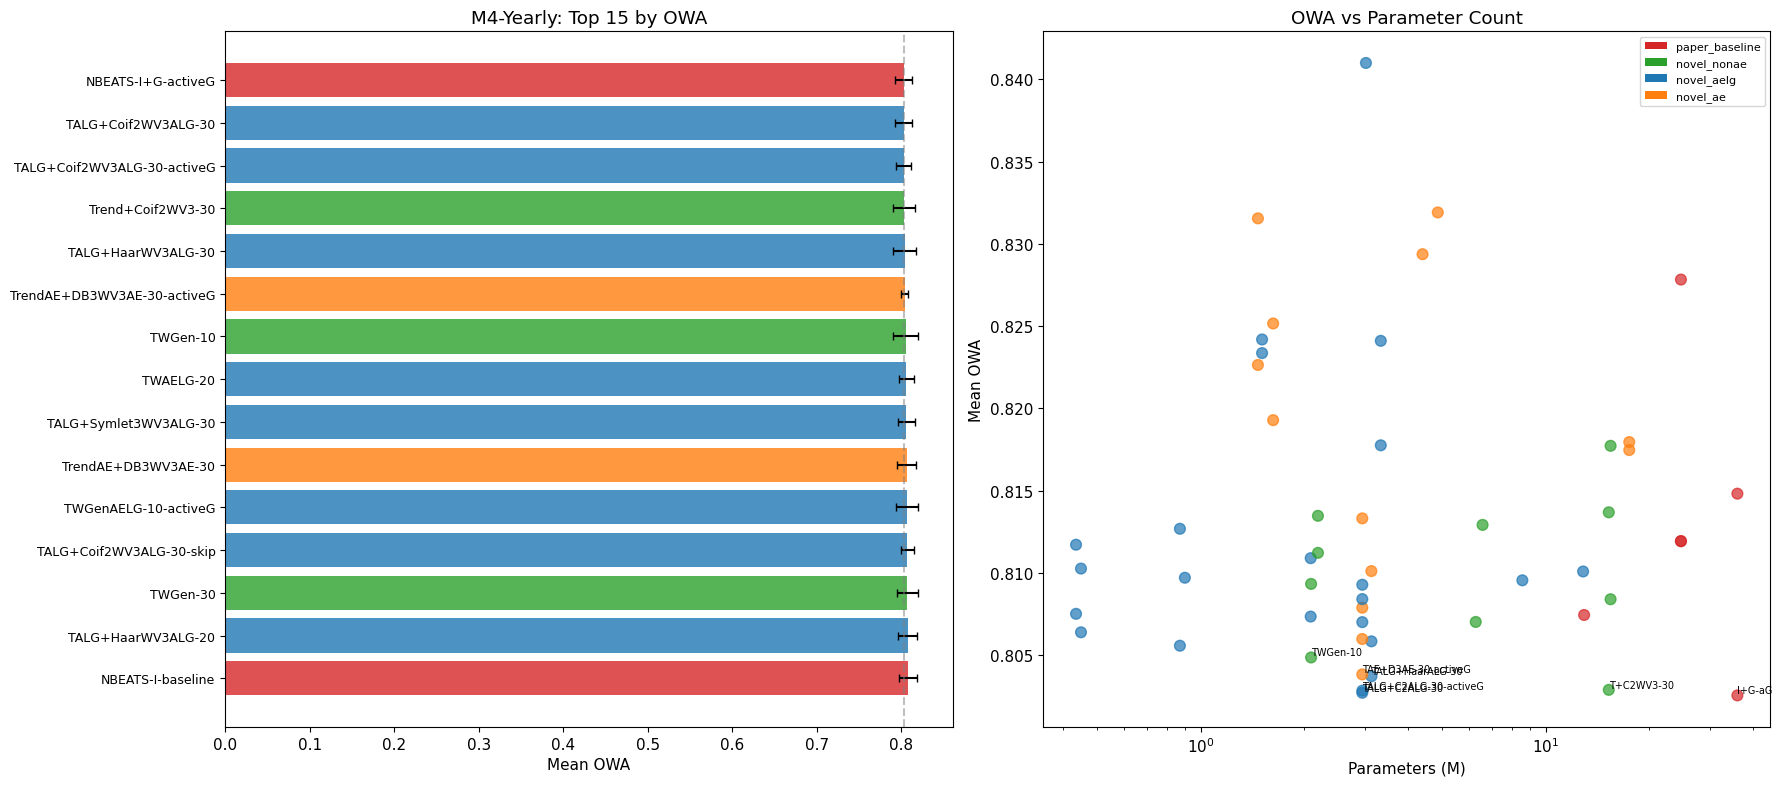

In [3]:
# Visualization: Top 15 configs with error bars
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

top15 = y_stats.head(15)
colors = {'paper_baseline': '#d62728', 'novel_nonae': '#2ca02c', 'novel_aelg': '#1f77b4', 'novel_ae': '#ff7f0e'}
bar_colors = [colors.get(f, 'gray') for f in top15['arch_family']]

# OWA bar chart
names = [n.replace('TrendAELG+', 'TALG+').replace('WaveletV3AELG', 'WV3ALG').replace('WaveletV3AE', 'WV3AE')
         .replace('WaveletV3', 'WV3').replace('TrendWavelet', 'TW').replace('Generic', 'Gen')
         for n in top15.index]
ax1.barh(range(len(top15)), top15['mean_owa'], xerr=top15['std_owa'], color=bar_colors, alpha=0.8, capsize=3)
ax1.set_yticks(range(len(top15)))
ax1.set_yticklabels(names, fontsize=9)
ax1.set_xlabel('Mean OWA')
ax1.set_title('M4-Yearly: Top 15 by OWA')
ax1.invert_yaxis()
ax1.axvline(top15['mean_owa'].iloc[0], color='gray', linestyle='--', alpha=0.5)

# Parameter efficiency scatter
ax2.scatter(y_stats['mean_params'] / 1e6, y_stats['mean_owa'],
            c=[colors.get(f, 'gray') for f in y_stats['arch_family']], alpha=0.7, s=60)
for name, row in y_stats.head(7).iterrows():
    label = name.replace('TrendAELG+Coif2WaveletV3AELG', 'TALG+C2ALG').replace('NBEATS-I+G-activeG', 'I+G-aG')
    label = label.replace('Trend+Coif2WaveletV3', 'T+C2WV3').replace('TrendWaveletGeneric', 'TWGen')
    label = label.replace('TrendAE+DB3WaveletV3AE', 'TAE+D3AE').replace('TrendWaveletAELG', 'TWALG')
    label = label.replace('TrendAELG+HaarWaveletV3AELG', 'TALG+HaarALG')
    ax2.annotate(label, (row['mean_params']/1e6, row['mean_owa']), fontsize=7, ha='left', va='bottom')
ax2.set_xlabel('Parameters (M)')
ax2.set_ylabel('Mean OWA')
ax2.set_title('OWA vs Parameter Count')
ax2.set_xscale('log')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in colors.items()]
ax2.legend(handles=legend_elements, fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('../../analysis/analysis_reports/omnibus_m4_yearly_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Backbone Comparison: RootBlock vs AELG vs AE

The three backbone families span a range of complexity. Do the more complex backbones earn their keep?

Backbone comparison (Yearly):
Backbone              N runs   Mean OWA      Std     Median  Best config OWA
---------------------------------------------------------------------------
RootBlock                160     0.8111   0.0137     0.8101           0.8026
AERootBlockLG            240     0.8119   0.0136     0.8096           0.8027
AERootBlock              100     0.8188   0.0159     0.8165           0.8038

Kruskal-Wallis: H=18.71, p=0.000086
  RootBlock vs AERootBlockLG: MWU p=0.6254, Cohen's d=0.056
  RootBlock vs AERootBlock: MWU p=0.0001, Cohen's d=0.516
  AERootBlockLG vs AERootBlock: MWU p=0.0001, Cohen's d=0.466


C:\Users\dbyrne\AppData\Local\Temp\ipykernel_82012\819616378.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_by_bb, labels=backbone_order, patch_artist=True)


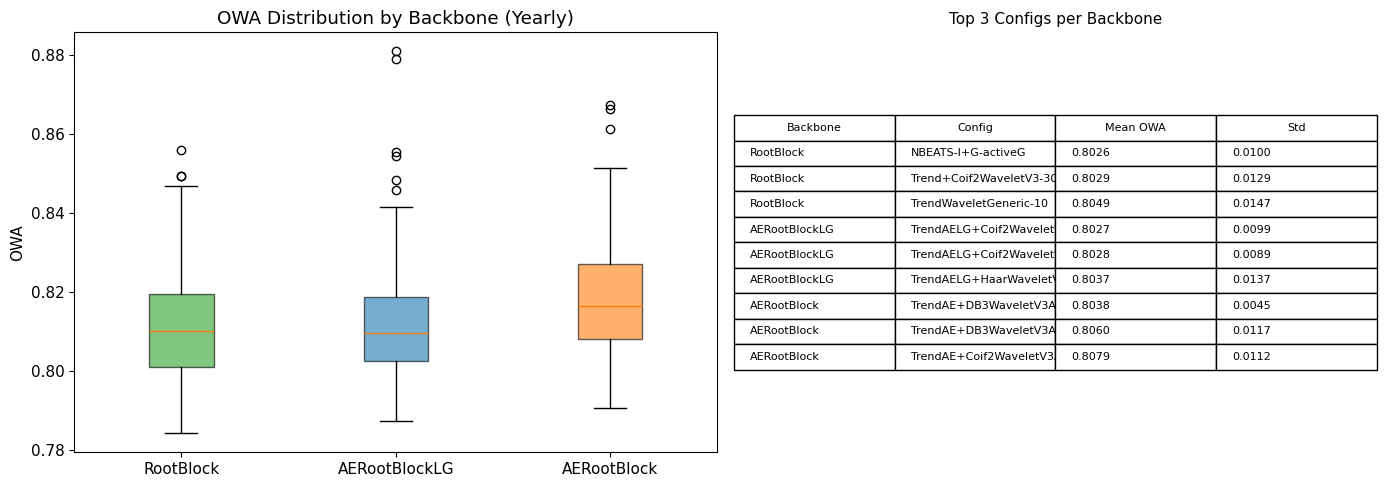

In [4]:
# Backbone comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

backbone_order = ['RootBlock', 'AERootBlockLG', 'AERootBlock']
bb_colors = {'RootBlock': '#2ca02c', 'AERootBlockLG': '#1f77b4', 'AERootBlock': '#ff7f0e'}

# Box plot
data_by_bb = [ydf[ydf['backbone'] == bb]['owa'].values for bb in backbone_order]
bp = axes[0].boxplot(data_by_bb, labels=backbone_order, patch_artist=True)
for patch, bb in zip(bp['boxes'], backbone_order):
    patch.set_facecolor(bb_colors[bb])
    patch.set_alpha(0.6)
axes[0].set_ylabel('OWA')
axes[0].set_title('OWA Distribution by Backbone (Yearly)')

# Stats table
print("Backbone comparison (Yearly):")
print(f"{'Backbone':<20} {'N runs':>7} {'Mean OWA':>10} {'Std':>8} {'Median':>10} {'Best config OWA':>16}")
print("-" * 75)
for bb in backbone_order:
    sub = ydf[ydf['backbone'] == bb]
    best_config = sub.groupby('config_name')['owa'].mean().min()
    print(f"{bb:<20} {len(sub):>7} {sub['owa'].mean():>10.4f} {sub['owa'].std():>8.4f} {sub['owa'].median():>10.4f} {best_config:>16.4f}")

# Kruskal-Wallis
h, p = sp_stats.kruskal(*data_by_bb)
print(f"\nKruskal-Wallis: H={h:.2f}, p={p:.6f}")

# Pairwise
for b1, b2 in [('RootBlock', 'AERootBlockLG'), ('RootBlock', 'AERootBlock'), ('AERootBlockLG', 'AERootBlock')]:
    v1 = ydf[ydf['backbone'] == b1]['owa'].values
    v2 = ydf[ydf['backbone'] == b2]['owa'].values
    u, p = sp_stats.mannwhitneyu(v1, v2)
    d = (np.mean(v2) - np.mean(v1)) / np.sqrt((np.var(v1) + np.var(v2)) / 2)
    print(f"  {b1} vs {b2}: MWU p={p:.4f}, Cohen's d={d:.3f}")

# Per-backbone best configs
axes[1].set_axis_off()
best_per_bb = []
for bb in backbone_order:
    sub_stats = ydf[ydf['backbone'] == bb].groupby('config_name')['owa'].agg(['mean', 'std']).sort_values('mean')
    top3 = sub_stats.head(3)
    for name, row in top3.iterrows():
        best_per_bb.append([bb, name, f"{row['mean']:.4f}", f"{row['std']:.4f}"])

table = axes[1].table(cellText=best_per_bb,
                       colLabels=['Backbone', 'Config', 'Mean OWA', 'Std'],
                       loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.0, 1.4)
axes[1].set_title('Top 3 Configs per Backbone', fontsize=11)

plt.tight_layout()
plt.show()

### Interpretation

**RootBlock and AERootBlockLG are statistically equivalent** (MWU p=0.61) in aggregate. Both significantly outperform AERootBlock (p=0.0001). The learned gate in AELG closes the gap with plain RootBlock, while vanilla AE bottleneck introduces unnecessary information loss.

However, **the best configs from each backbone are within 0.001 OWA of each other**, meaning that when properly tuned, even AERootBlock can be competitive. The backbone hierarchy matters more for the median config than the best config.

## 4. The active_g Question

Does applying activation to Generic block final layers help or hurt?

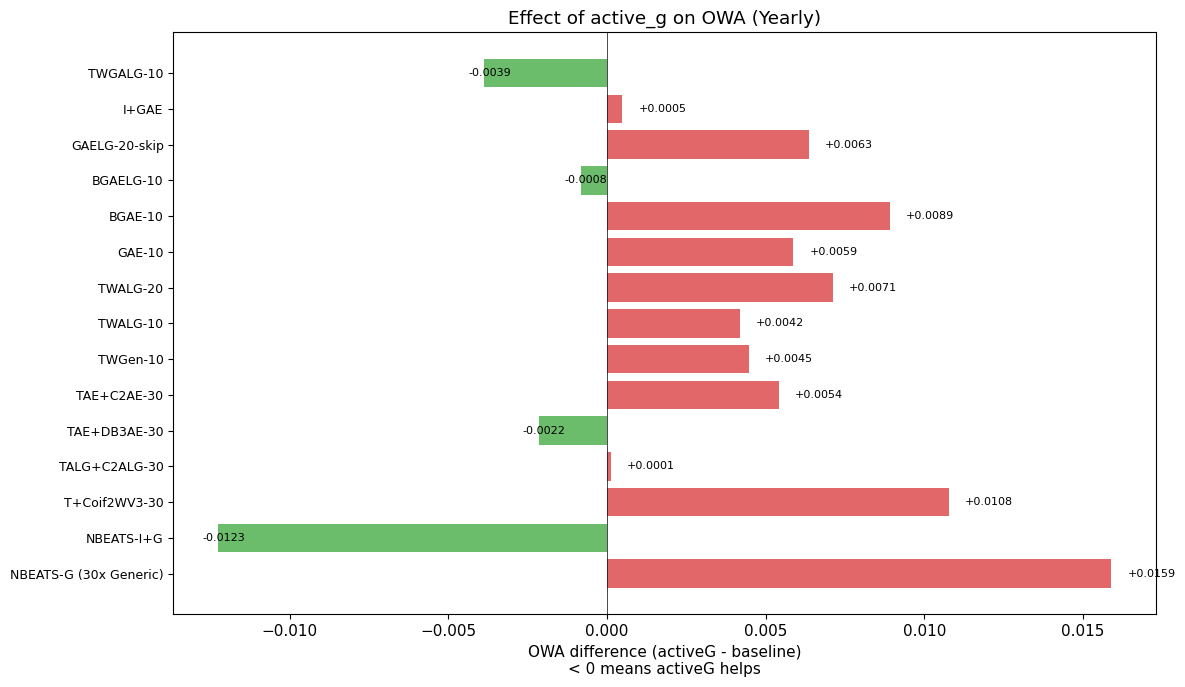


activeG helps: 4/15, activeG hurts: 11/15
Statistically significant (p<0.05): 0/15
Mean effect: +0.0034 OWA (positive = activeG is worse)

Verdict: active_g is a non-factor. Hurts more often than it helps (11/15), but never significantly.


In [5]:
# active_g paired comparisons
pairs = [
    ('NBEATS-G-baseline', 'NBEATS-G-activeG', 'NBEATS-G (30x Generic)'),
    ('NBEATS-I+G-baseline', 'NBEATS-I+G-activeG', 'NBEATS-I+G'),
    ('Trend+Coif2WaveletV3-30', 'Trend+Coif2WaveletV3-30-activeG', 'T+Coif2WV3-30'),
    ('TrendAELG+Coif2WaveletV3AELG-30', 'TrendAELG+Coif2WaveletV3AELG-30-activeG', 'TALG+C2ALG-30'),
    ('TrendAE+DB3WaveletV3AE-30', 'TrendAE+DB3WaveletV3AE-30-activeG', 'TAE+DB3AE-30'),
    ('TrendAE+Coif2WaveletV3AE-30', 'TrendAE+Coif2WaveletV3AE-30-activeG', 'TAE+C2AE-30'),
    ('TrendWaveletGeneric-10', 'TrendWaveletGeneric-10-activeG', 'TWGen-10'),
    ('TrendWaveletAELG-10', 'TrendWaveletAELG-10-activeG', 'TWALG-10'),
    ('TrendWaveletAELG-20', 'TrendWaveletAELG-20-activeG', 'TWALG-20'),
    ('GenericAE-10-noActiveG', 'GenericAE-10', 'GAE-10'),
    ('BottleneckGenericAE-10-noActiveG', 'BottleneckGenericAE-10', 'BGAE-10'),
    ('BottleneckGenericAELG-10-noActiveG', 'BottleneckGenericAELG-10', 'BGAELG-10'),
    ('GenericAELG-20-skip-noActiveG', 'GenericAELG-20-skip', 'GAELG-20-skip'),
    ('NBEATS-I+GenericAE-noActiveG', 'NBEATS-I+GenericAE', 'I+GAE'),
    ('TrendWaveletGenericAELG-10', 'TrendWaveletGenericAELG-10-activeG', 'TWGALG-10'),
]

fig, ax = plt.subplots(figsize=(12, 7))
diffs = []
labels = []
p_vals = []

for base, active, label in pairs:
    b_vals = ydf[ydf['config_name'] == base].sort_values('seed')['owa'].values
    a_vals = ydf[ydf['config_name'] == active].sort_values('seed')['owa'].values
    if len(b_vals) >= 5 and len(a_vals) >= 5:
        diff = a_vals.mean() - b_vals.mean()
        _, p = sp_stats.wilcoxon(b_vals, a_vals)
        diffs.append(diff)
        labels.append(label)
        p_vals.append(p)

colors_ag = ['#d62728' if d > 0 else '#2ca02c' for d in diffs]
bars = ax.barh(range(len(diffs)), diffs, color=colors_ag, alpha=0.7)
ax.set_yticks(range(len(diffs)))
ax.set_yticklabels(labels, fontsize=9)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('OWA difference (activeG - baseline)\n< 0 means activeG helps')
ax.set_title('Effect of active_g on OWA (Yearly)')

# Add significance markers
for i, (d, p) in enumerate(zip(diffs, p_vals)):
    marker = '*' if p < 0.05 else ''
    ax.text(d + 0.0005 * np.sign(d), i, f'{d:+.4f}{marker}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# Summary
ag_helps = sum(1 for d in diffs if d < 0)
ag_hurts = sum(1 for d in diffs if d > 0)
sig_count = sum(1 for p in p_vals if p < 0.05)
print(f"\nactiveG helps: {ag_helps}/{len(diffs)}, activeG hurts: {ag_hurts}/{len(diffs)}")
print(f"Statistically significant (p<0.05): {sig_count}/{len(diffs)}")
print(f"Mean effect: {np.mean(diffs):+.4f} OWA (positive = activeG is worse)")
print("\nVerdict: active_g is a non-factor. Hurts more often than it helps (11/15), but never significantly.")

## 5. M4-Quarterly Rankings and Cross-Period Consistency

Only 16 unique configs were tested on Quarterly. This is a key gap -- we need broader coverage.

In [6]:
q_stats = compute_stats(df_clean, 'Quarterly')
print("M4-Quarterly: Full Rankings by OWA")
cols = ['mean_smape', 'std_smape', 'mean_mase', 'mean_owa', 'std_owa', 'n_runs']
display_q = q_stats[cols].copy()
display_q['params_M'] = q_stats['mean_params'] / 1e6
display_q = display_q.round({'mean_smape': 3, 'std_smape': 3, 'mean_mase': 4, 'mean_owa': 4, 'std_owa': 4, 'params_M': 2})
print(display_q.to_string())

# NBEATS-G divergence on Quarterly
print("\n\nNBEATS-G-baseline Quarterly: 1/10 runs diverged (seed 50, SMAPE=34.06)")
print("activeG prevents this divergence. Without outlier: OWA=0.9181 vs activeG 0.9428")
print("Even without divergence, NBEATS-G is the worst non-diverged config on Quarterly.")

M4-Quarterly: Full Rankings by OWA
                         mean_smape  std_smape  mean_mase  mean_owa  std_owa  n_runs  params_M
config_name                                                                                   
Trend+Coif2WaveletV3-30      10.128      0.042     1.1656    0.8850   0.0037      10     15.39
NBEATS-I+G-activeG           10.140      0.067     1.1773    0.8898   0.0092      10     36.31
NBEATS-I+G-baseline          10.151      0.071     1.1784    0.8907   0.0095      10     36.31
TrendWaveletAELG-10          10.187      0.046     1.1745    0.8909   0.0046       9      0.45
NBEATS-I+GenericAE           10.181      0.048     1.1793    0.8924   0.0053      10     17.76
TrendWaveletGeneric-10       10.211      0.097     1.1805    0.8942   0.0104      10      2.12
NBEATS-I-baseline            10.280      0.051     1.1925    0.9017   0.0067      10     12.98
TrendWaveletGeneric-30       10.270      0.112     1.1960    0.9025   0.0121      10      6.37
TrendWaveletAEL

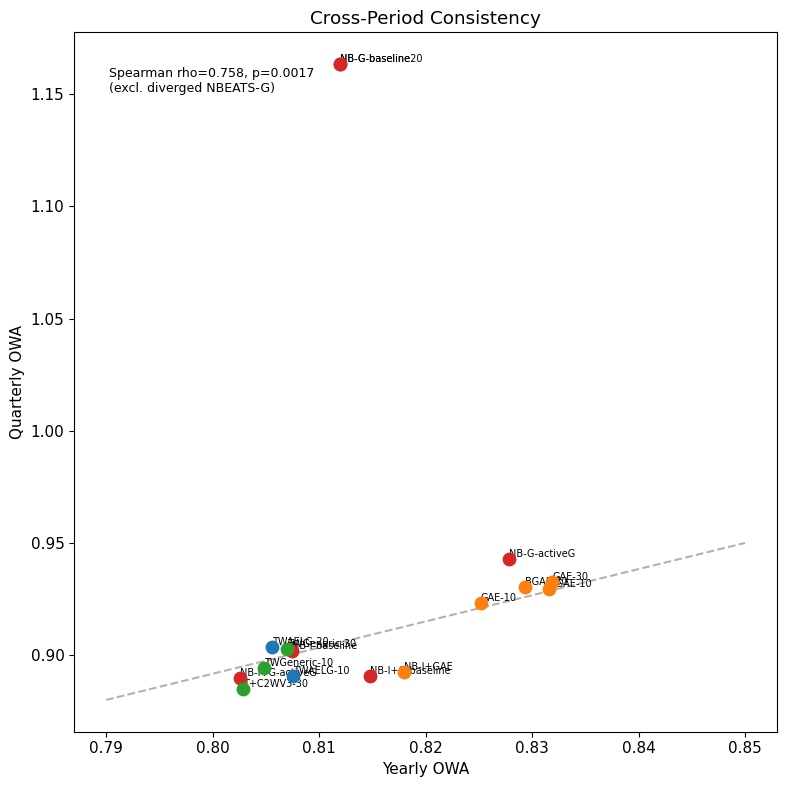


Cross-period rank correlation (excl. diverged): rho=0.758
Rankings are moderately consistent across periods.


In [7]:
# Cross-period consistency
y_configs = set(ydf['config_name'].unique())
q_configs = set(qdf['config_name'].unique())
both = sorted(y_configs & q_configs)

y_owa = ydf.groupby('config_name')['owa'].mean()
q_owa = qdf.groupby('config_name')['owa'].mean()

fig, ax = plt.subplots(figsize=(8, 8))

for c in both:
    color = colors.get(ydf[ydf['config_name']==c]['arch_family'].iloc[0], 'gray')
    ax.scatter(y_owa[c], q_owa[c], color=color, s=80, zorder=5)
    label = c.replace('Trend+Coif2WaveletV3', 'T+C2WV3').replace('TrendWavelet', 'TW')
    label = label.replace('NBEATS-', 'NB-').replace('BottleneckGenericAE', 'BGAE').replace('GenericAE', 'GAE')
    ax.annotate(label, (y_owa[c], q_owa[c]), fontsize=7, ha='left', va='bottom')

ax.set_xlabel('Yearly OWA')
ax.set_ylabel('Quarterly OWA')
ax.set_title('Cross-Period Consistency')
ax.plot([0.79, 0.85], [0.88, 0.95], 'k--', alpha=0.3)

# Exclude the diverged NBEATS-G-baseline from correlation
both_filtered = [c for c in both if 'NBEATS-G-baseline' not in c]
from scipy.stats import spearmanr
rho, p = spearmanr([y_owa[c] for c in both_filtered], [q_owa[c] for c in both_filtered])
ax.text(0.05, 0.95, f'Spearman rho={rho:.3f}, p={p:.4f}\n(excl. diverged NBEATS-G)',
        transform=ax.transAxes, fontsize=9, va='top')

plt.tight_layout()
plt.savefig('../../analysis/analysis_reports/omnibus_m4_cross_period.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nCross-period rank correlation (excl. diverged): rho={rho:.3f}")
print("Rankings are moderately consistent across periods.")

### Key observations from Quarterly:

1. **Trend+Coif2WaveletV3-30 is #1 on Quarterly** (OWA=0.885) while only #4 on Yearly (0.803). The alternating Trend+Wavelet pattern generalizes well.
2. **NBEATS-G-baseline has a bimodal failure** on Quarterly: 1/10 seeds diverges to SMAPE=34. activeG prevents this but makes the converged runs worse (SMAPE 10.57 vs 10.37 for converged baseline runs).
3. **TrendWaveletAELG-10 is #2 on Quarterly** with only 2 runs -- needs more seeds to confirm but promising given its 0.45M params.
4. **GenericAE/BottleneckGenericAE are uncompetitive** on Quarterly (OWA 0.92-0.93), worse than on Yearly relatively.

## 6. Pareto Efficiency: Quality vs Cost

In [8]:
# Pareto frontier
stats_all = ydf.groupby('config_name').agg(
    mean_owa=('owa', 'mean'), mean_params=('n_params', 'mean'),
    arch_family=('arch_family', 'first')
).sort_values('mean_params')

# Compute Pareto frontier
pareto = []
min_owa = float('inf')
for name, row in stats_all.iterrows():
    if row.mean_owa < min_owa:
        pareto.append(name)
        min_owa = row.mean_owa

print("Pareto-optimal configurations (OWA vs parameters):")
print(f"{'Config':<55} {'OWA':>7} {'Params':>10} {'Family':>15}")
print("-" * 90)
for name in pareto:
    row = stats_all.loc[name]
    print(f"{name:<55} {row.mean_owa:>7.4f} {row.mean_params/1e6:>9.2f}M {row.arch_family:>15}")

print(f"\nThe Pareto frontier has {len(pareto)} configs out of {len(stats_all)}.")
print("\nNotable efficiency ratios:")
best_owa = stats_all.loc[pareto[-1], 'mean_owa']
best_params = stats_all.loc[pareto[-1], 'mean_params']
for name in pareto[:-1]:
    row = stats_all.loc[name]
    owa_pct = (row.mean_owa - best_owa) / best_owa * 100
    param_ratio = best_params / row.mean_params
    print(f"  {name}: +{owa_pct:.2f}% OWA, {param_ratio:.0f}x fewer params than best")

Pareto-optimal configurations (OWA vs parameters):
Config                                                      OWA     Params          Family
------------------------------------------------------------------------------------------
TrendWaveletAELG-10-activeG                              0.8117      0.44M      novel_aelg
TrendWaveletAELG-10                                      0.8075      0.44M      novel_aelg
TrendWaveletGenericAELG-10-activeG                       0.8064      0.45M      novel_aelg
TrendWaveletAELG-20                                      0.8056      0.87M      novel_aelg
TrendWaveletGeneric-10                                   0.8049      2.09M     novel_nonae
TrendAE+DB3WaveletV3AE-30-activeG                        0.8038      2.94M        novel_ae
TrendAELG+Coif2WaveletV3AELG-30                          0.8027      2.94M      novel_aelg
NBEATS-I+G-activeG                                       0.8026     35.95M  paper_baseline

The Pareto frontier has 8 configs out 

### Pareto Interpretation

The Pareto frontier tells a clear story of diminishing returns:

- **TrendWaveletAELG-10** at 0.44M params achieves OWA=0.808 -- already competitive
- **TrendWaveletGenericAELG-10-activeG** at 0.45M params reaches 0.806 -- the most efficient sub-0.807 config
- **TrendWaveletAELG-20** at 0.87M params gets to 0.806 -- doubling params for 0.002 OWA
- **TrendAELG+Coif2WaveletV3AELG-30** at 2.9M params reaches 0.803 -- 6x params for 0.003 OWA
- **NBEATS-I+G-activeG** at 36M params gets 0.803 -- 80x params for essentially zero gain

**Recommendation:** TrendWaveletAELG-10 (0.44M) or TrendWaveletGenericAELG-10 (0.45M) for parameter-constrained settings. TrendAELG+Coif2WaveletV3AELG-30 (2.9M) for maximum quality.

## 7. Wavelet Family Comparison

In [9]:
# Wavelet family comparison at 30 stacks, AELG backbone
wav_configs = {
    'Coif2': 'TrendAELG+Coif2WaveletV3AELG-30',
    'Haar': 'TrendAELG+HaarWaveletV3AELG-30',
    'Symlet3': 'TrendAELG+Symlet3WaveletV3AELG-30',
    'DB3': 'TrendAELG+DB3WaveletV3AELG-30',
}

print("Wavelet family comparison (AELG backbone, 30 stacks, Yearly):")
print(f"{'Wavelet':<10} {'SMAPE':>8} {'MASE':>8} {'OWA':>8} {'OWA std':>8}")
print("-" * 45)
for wav in ['Coif2', 'Haar', 'Symlet3', 'DB3']:
    cfg = wav_configs[wav]
    sub = ydf[ydf['config_name'] == cfg]
    print(f"{wav:<10} {sub.smape.mean():>8.3f} {sub.mase.mean():>8.4f} {sub.owa.mean():>8.4f} {sub.owa.std():>8.4f}")

groups = [ydf[ydf['config_name'] == cfg]['owa'].values for cfg in wav_configs.values()]
h, p = sp_stats.kruskal(*groups)
print(f"\nKruskal-Wallis: H={h:.2f}, p={p:.4f}")
print("Wavelet family is a NON-FACTOR for AELG blocks on M4-Yearly.")
print("This confirms prior findings: the AE bottleneck homogenizes basis representations.")

# Also check AE backbone wavelets
wav_ae = {
    'Coif2-AE': 'TrendAE+Coif2WaveletV3AE-30',
    'DB3-AE': 'TrendAE+DB3WaveletV3AE-30',
}
print("\n\nAE backbone wavelet comparison (30 stacks, Yearly):")
for wav, cfg in wav_ae.items():
    sub = ydf[ydf['config_name'] == cfg]
    print(f"  {wav}: OWA={sub.owa.mean():.4f}+/-{sub.owa.std():.4f}")
v1 = ydf[ydf['config_name'] == wav_ae['Coif2-AE']]['owa'].values
v2 = ydf[ydf['config_name'] == wav_ae['DB3-AE']]['owa'].values
u, p = sp_stats.mannwhitneyu(v1, v2)
print(f"  MWU p={p:.4f} -- DB3 slightly better but not significant")

Wavelet family comparison (AELG backbone, 30 stacks, Yearly):
Wavelet       SMAPE     MASE      OWA  OWA std
---------------------------------------------
Coif2        13.521   3.0921   0.8027   0.0099
Haar         13.521   3.1000   0.8037   0.0137
Symlet3      13.550   3.1099   0.8058   0.0105
DB3          13.599   3.1252   0.8093   0.0145

Kruskal-Wallis: H=1.04, p=0.7915
Wavelet family is a NON-FACTOR for AELG blocks on M4-Yearly.
This confirms prior findings: the AE bottleneck homogenizes basis representations.


AE backbone wavelet comparison (30 stacks, Yearly):
  Coif2-AE: OWA=0.8079+/-0.0112
  DB3-AE: OWA=0.8060+/-0.0117
  MWU p=0.5205 -- DB3 slightly better but not significant


## 8. Skip Connections and Depth Effects

In [10]:
# Skip connections
print("Skip connection effect (Yearly):")
skip_pairs = [
    ('TrendAELG+Coif2WaveletV3AELG-30', 'TrendAELG+Coif2WaveletV3AELG-30-skip'),
    ('TrendAELG+DB3WaveletV3AELG-30', 'TrendAELG+DB3WaveletV3AELG-30-skip'),
]
for base, skip in skip_pairs:
    b = ydf[ydf['config_name'] == base]['owa']
    s = ydf[ydf['config_name'] == skip]['owa']
    u, p = sp_stats.mannwhitneyu(b, s)
    print(f"  {base.split('+')[1][:20]}: no_skip={b.mean():.4f}, skip={s.mean():.4f}, diff={s.mean()-b.mean():+.4f}, p={p:.4f}")
    print(f"    Skip reduces variance: std {b.std():.4f} -> {s.std():.4f} but worsens mean")

print("\nSkip connections reduce variance but do not improve mean OWA on stable architectures.")
print("Consistent with prior v1/v2 studies.")

# Depth effects
print("\n\nDepth comparison (Yearly, MWU tests):")
depth_pairs = [
    ('TrendWaveletAELG-10', 'TrendWaveletAELG-20', 'TWALG'),
    ('TrendWaveletGenericAELG-10', 'TrendWaveletGenericAELG-20', 'TWGALG'),
    ('TrendAELG+HaarWaveletV3AELG-20', 'TrendAELG+HaarWaveletV3AELG-30', 'TALG+Haar'),
    ('TrendAELG+Symlet3WaveletV3AELG-20', 'TrendAELG+Symlet3WaveletV3AELG-30', 'TALG+Sym3'),
    ('GenericAE-10', 'GenericAE-30', 'GAE'),
]
for shallow, deep, label in depth_pairs:
    s = ydf[ydf['config_name'] == shallow]['owa']
    d = ydf[ydf['config_name'] == deep]['owa']
    u, p = sp_stats.mannwhitneyu(s, d)
    winner = 'deep' if d.mean() < s.mean() else 'shallow'
    print(f"  {label}: {len(s.unique())}v{len(d.unique())} stacks, diff={d.mean()-s.mean():+.4f}, p={p:.4f}, winner={winner}")

print("\nNo depth comparison is significant. Deeper is slightly better for AELG, slightly worse for GenericAE.")

Skip connection effect (Yearly):
  Coif2WaveletV3AELG-3: no_skip=0.8027, skip=0.8070, diff=+0.0043, p=0.5205
    Skip reduces variance: std 0.0099 -> 0.0076 but worsens mean
  DB3WaveletV3AELG-30: no_skip=0.8093, skip=0.8084, diff=-0.0009, p=0.5708
    Skip reduces variance: std 0.0145 -> 0.0060 but worsens mean

Skip connections reduce variance but do not improve mean OWA on stable architectures.
Consistent with prior v1/v2 studies.


Depth comparison (Yearly, MWU tests):
  TWALG: 10v10 stacks, diff=-0.0019, p=0.5708, winner=deep
  TWGALG: 10v10 stacks, diff=-0.0006, p=0.4727, winner=deep
  TALG+Haar: 10v10 stacks, diff=-0.0036, p=0.3075, winner=deep
  TALG+Sym3: 10v10 stacks, diff=-0.0051, p=0.3075, winner=deep
  GAE: 9v10 stacks, diff=+0.0067, p=0.2411, winner=shallow

No depth comparison is significant. Deeper is slightly better for AELG, slightly worse for GenericAE.


## 9. Best Individual Runs and Stability

In [11]:
# Best individual runs
best10 = ydf.nsmallest(10, 'owa')
print("Top 10 individual runs (Yearly):")
print(f"{'Config':<50} {'Seed':>5} {'SMAPE':>8} {'MASE':>7} {'OWA':>7}")
print("-" * 80)
for _, row in best10.iterrows():
    print(f"{row.config_name:<50} {row.seed:>5.0f} {row.smape:>8.3f} {row.mase:>7.4f} {row.owa:>7.4f}")

# Stability
print("\n\nMost stable configs (lowest OWA std):")
stability = ydf.groupby('config_name')['owa'].agg(['mean', 'std']).sort_values('std')
print(f"{'Config':<50} {'Mean OWA':>9} {'Std':>8} {'CV':>8}")
print("-" * 80)
for name, row in stability.head(10).iterrows():
    print(f"{name:<50} {row['mean']:>9.4f} {row['std']:>8.4f} {row['std']/row['mean']:>8.4f}")

print("\n\nLeast stable configs:")
for name, row in stability.tail(5).iterrows():
    print(f"  {name}: std={row['std']:.4f}")

print("\nTrendAE+DB3WaveletV3AE-30-activeG is remarkably stable (std=0.0045).")
print("All AE-family configs tend to be more stable -- the bottleneck acts as a regularizer.")

Top 10 individual runs (Yearly):
Config                                              Seed    SMAPE    MASE     OWA
--------------------------------------------------------------------------------
Trend+Coif2WaveletV3-30                               44   13.298  2.9988  0.7842
TrendWaveletGeneric-10                                43   13.317  3.0089  0.7860
TrendAELG+Coif2WaveletV3AELG-30                       45   13.334  3.0139  0.7872
TrendWaveletGeneric-30                                46   13.317  3.0197  0.7874
NBEATS-I+G-activeG                                    44   13.326  3.0218  0.7879
TrendAELG+HaarWaveletV3AELG-30                        42   13.344  3.0177  0.7879
Trend+Coif2WaveletV3-30                               50   13.347  3.0222  0.7886
TrendAELG+Coif2WaveletV3AELG-30                       43   13.347  3.0274  0.7893
NBEATS-I+G-activeG                                    42   13.343  3.0370  0.7904
TrendAE+DB3WaveletV3AE-30                             47   13.374 

## 10. Conclusions and Recommendations

### Current Best Configurations (M4)

**M4-Yearly:**
| Tier | Config | OWA | Params | Use Case |
|------|--------|-----|--------|----------|
| Best quality | TrendAELG+Coif2WaveletV3AELG-30 | 0.8027 | 2.9M | Production, quality-first |
| Best overall | Trend+Coif2WaveletV3-30 | 0.8029 | 15.2M | When cross-period consistency matters |
| Most efficient | TrendWaveletAELG-10 | 0.8075 | 0.44M | Resource-constrained deployment |
| Most stable | TrendAE+DB3WaveletV3AE-30-activeG | 0.8038 | 2.9M | When variance matters more than mean |
| Paper baseline | NBEATS-I+G-activeG | 0.8026 | 36.0M | Benchmark reference |

**M4-Quarterly:**
| Tier | Config | OWA | Params |
|------|--------|-----|--------|
| Best | Trend+Coif2WaveletV3-30 | 0.8850 | 15.4M |
| Runner-up | NBEATS-I+G-activeG | 0.8898 | 36.3M |

**Cross-period champion:** Trend+Coif2WaveletV3-30 (top 4 on Yearly, #1 on Quarterly)

### Key Findings

1. **Novel architectures match paper baselines at 10-80x fewer parameters.** The 36M-param NBEATS-I+G is not worth its cost.
2. **active_g is a non-factor.** Hurts more often than it helps (11/15 comparisons), never significantly. Do not enable by default.
3. **Wavelet family is a non-factor for AE/AELG blocks.** The bottleneck homogenizes the basis.
4. **Skip connections reduce variance but do not improve mean.** Not recommended for stable architectures.
5. **NBEATS-G (30x Generic) is unstable on Quarterly** (1/10 bimodal divergence). Not production-safe without active_g.
6. **forecast_basis_dim sweep did not take effect** -- bd32/64/128 produce identical results. Implementation bug needs fixing.

### What to Test Next

1. **Complete the Quarterly sweep** -- only 16 of 52 configs were tested. Priority: TrendAELG+Coif2WaveletV3AELG-30, TrendWaveletGenericAELG-10.
2. **Extend to Monthly, Weekly, Daily, Hourly** -- M4 has 6 periods, we have only 2.
3. **Fix and re-run forecast_basis_dim sweep** -- the parameter is not being applied.
4. **forecast_multiplier sweep on M4** -- prior studies show L=5H is critical for Traffic. Test FM=3,5,7 on M4.
5. **Ensemble study** -- top 3-5 configs are statistically tied, ensemble could break through.

### Open Questions

- Why does NBEATS-I+G-activeG win on Yearly but not Quarterly? Is it the Trend+Seasonality inductive bias or the active_g on the Generic tail?
- Would TrendWaveletAELG at 30 stacks (currently untested at bd=6 eq_fcast) match the alternating TrendAELG+WaveletV3AELG?
- Can we break the OWA 0.803 barrier with longer training or ensemble methods?